[Новый набор данных для медицинской визуализации (КТ-рентген)](https://www.kaggle.com/datasets/shuvokumarbasakbd/brain-ct-medical-imaging-colorized-dataset, "Ссылка на медицинские данные")


# 1. Подготовка и анализ данных

In [ ]:
import zipfile
import io, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# **I. Подготовка и анализ данных**

## Загрузка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Если архив, долго
path_data_zip = ('/content/drive/MyDrive/DFD_Учёба/Домашнее Задание/Data Science в медицине/'
                 'ПЗ_№2_Машинное обучение и компьютерное зрение для обработки медицинских данных/dataset.zip')
""""with zipfile.ZipFile(file=path_data_zip) as zip_data:
  list_file = [list_.filename for list_ in zip_data.filelist]
  print(f'Содержимое основного архива:\n{list_file}')

  for filename in list_file:
    if filename.endswith('.zip'):               # endswith()- это метод строки в Python
      nested_zip_data = zip_data.read(filename) # Читаем вложенный архив в память!!!

      with zipfile.ZipFile(io.BytesIO(nested_zip_data)) as nested_zip:
          nested_zip.extractall()
    else:
      zip_data.extractall()"""

'"with zipfile.ZipFile(file=path_data_zip) as zip_data:\n  list_file = [list_.filename for list_ in zip_data.filelist]\n  print(f\'Содержимое основного архива:\n{list_file}\')\n\n  for filename in list_file:\n    if filename.endswith(\'.zip\'):               # endswith()- это метод строки в Python\n      nested_zip_data = zip_data.read(filename) # Читаем вложенный архив в память!!!\n\n      with zipfile.ZipFile(io.BytesIO(nested_zip_data)) as nested_zip:\n          nested_zip.extractall()\n    else:\n      zip_data.extractall()'

In [ ]:
DATASET_ROOT = '/content/drive/MyDrive/DFD_Учёба/Домашнее Задание/Data Science в медицине'
train_dir = os.path.join(DATASET_ROOT, 'ПЗ_№2_Машинное обучение и компьютерное зрение для обработки медицинских данных/dataset/train')
test_dir = os.path.join(DATASET_ROOT, 'ПЗ_№2_Машинное обучение и компьютерное зрение для обработки медицинских данных/dataset/test' )

In [ ]:
classes_label = os.listdir(train_dir)
print(classes_label)

['aneurysm', 'cancer', 'tumor']


In [ ]:
def collect_data(root_dir, classes):
  "функция формирования датафрейма с указанием пути каждого файла и к какому классу относится файл"
  data = []
  for label, class_name in enumerate(classes):
      class_path = os.path.join(root_dir, class_name)  # путь к папкам конкретных классов
      for img_name in os.listdir(class_path):
        full_path = os.path.join(class_path, img_name)
        data.append({'path_dir': full_path, 'label': label})
  return pd.DataFrame(data)

In [ ]:
df_train = collect_data(train_dir, classes_label)
df_test = collect_data(test_dir, classes_label)
print(f'Размер обучающей выборки: {df_train.shape}\nРазмер тестовой выборки: {df_test.shape}')

Размер обучающей выборки: (2590, 2)
Размер тестовой выборки: (144, 2)


In [ ]:
df_train.head()

,path_dir,label
0,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0
1,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0
2,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0
3,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0
4,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0


In [ ]:
# добавляю столбец с классами патологии
df_train['pathology_class'] = df_train['label'].replace({
    0: 'aneurysm',
    1: 'cancer',
    2: 'tumor'
})

In [ ]:
df_train.head()

,path_dir,label,pathology_class
0,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0,aneurysm
1,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0,aneurysm
2,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0,aneurysm
3,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0,aneurysm
4,/content/drive/MyDrive/DFD_Учёба/Домашнее Зад...,0,aneurysm


##1. Первичный анализ датасета

In [ ]:
# A) Количество изображений в каждом классе (метка-label):
df_train.label.value_counts()

,count
label,
1,910
0,840
2,840


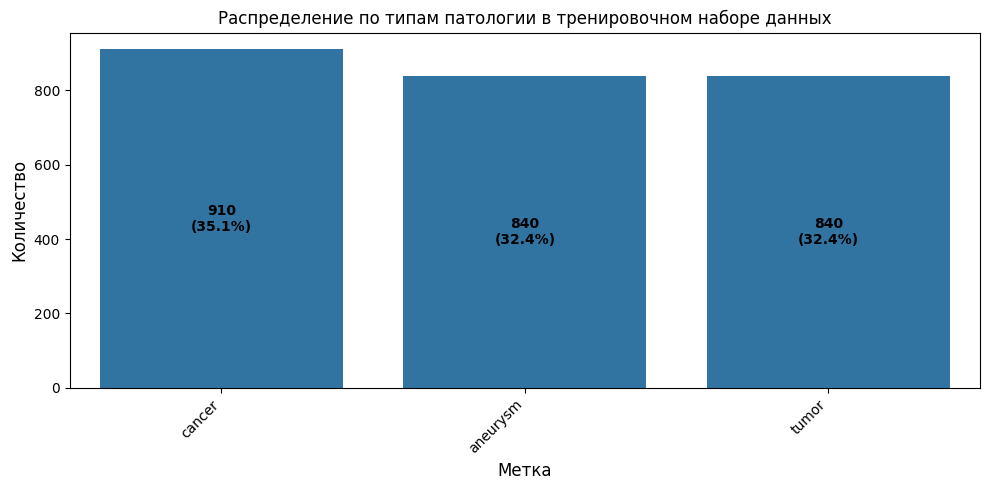

In [ ]:
# B) Анализ распределения по типам патологии:

counts = df_train.pathology_class.value_counts()
# проценты
total = counts.sum()
percentages = counts / total * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=counts.index, y=counts.values)

# Аннотации с количеством и процентами
for i, (count, percentage) in enumerate(zip(counts.values, percentages)):
    ax.text(i, count/2, f'{count}\n({percentage:.1f}%)',
            ha='center', va='center', fontweight='bold')

# график
plt.title('Распределение по типам патологии в тренировочном наборе данных')
plt.xlabel('Метка', size=12)
plt.ylabel('Количество', size=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
# C) Оценка качества изображений (наличие артефактов, шумов):
from PIL import Image, ImageDraw
def plot_random_grid(df, target_class, path='path_dir', grid_size=2): # 'path_dir' - собственный путь к изображения

    # Выберем случайные изображения из класса
    samples = df[df['label'] == target_class].sample(grid_size**2)

    # Создание сетки построения графика
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    fig.suptitle(f'{target_class} Samples', fontsize=14)

    for i, ax in enumerate(axes.flat):
        img = Image.open(samples.iloc[i][path])
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

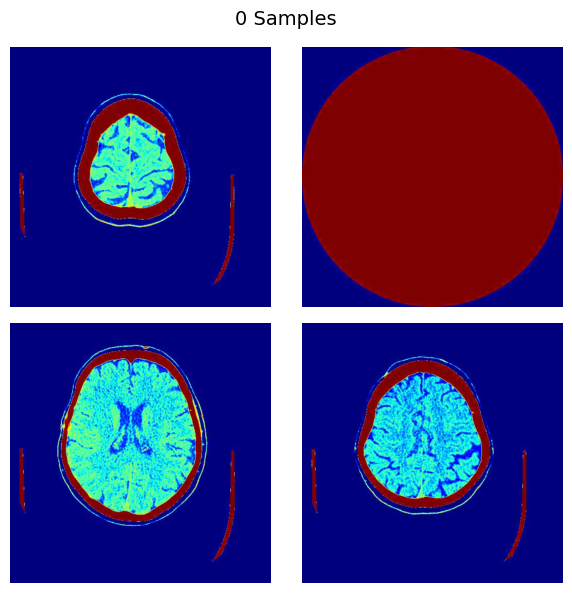

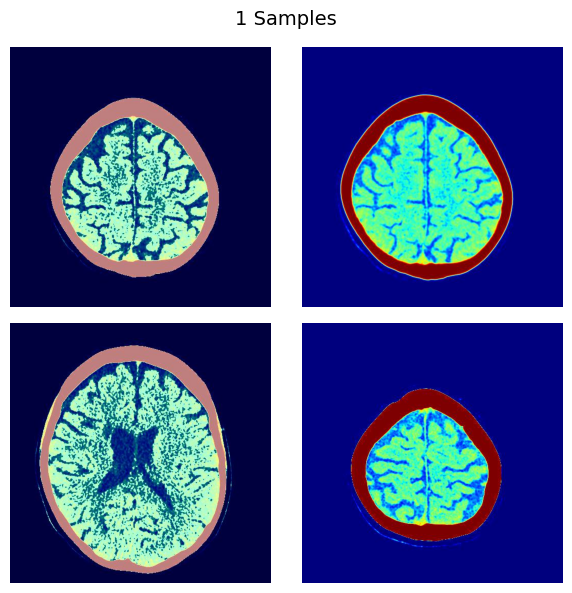

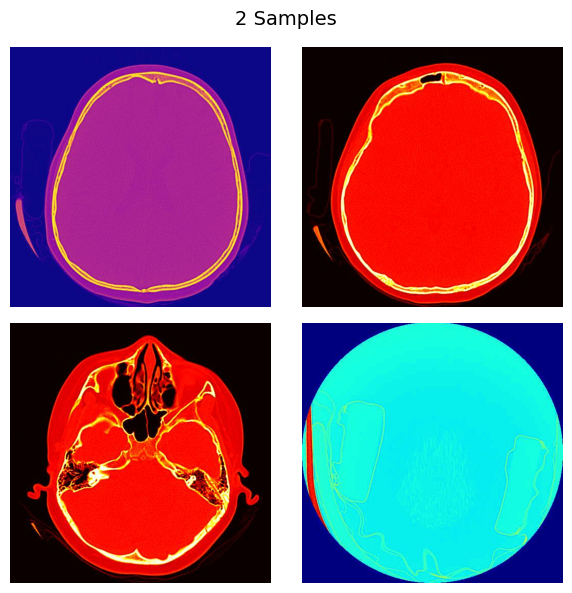

In [ ]:
# Выборки для каждого класса в наборе данных
for cls in df_train.label.unique():
    plot_random_grid(df_train, cls)

In [ ]:
# Есть артефакты и шумы?

##2. Предобработка данных

In [ ]:
# формирование валидационной - 15%, обучающей - 85% (набор из df_train!). Для теста отдельные изображения - df_test
from sklearn.model_selection import train_test_split

# Сначала отделяем тестовую выборку (например, 10% от всех данных)
train_df, val_df = train_test_split(df_train, test_size=0.15, random_state=1982)

In [ ]:
# ДОЛГО. ЛУЧШЕ ИСПОЛЬЗОВАТЬ ГЕНЕРАТОР
# Преобразование изображений к единому размеру (224*224)
import cv2
IMG_WIDTH = 224
IMG_HEIGHT = 224
IMG_CHANNELS = 3

# Функция загрузки и предобработки изображения
def load_and_preprocess_image(path):
    img = cv2.imread(path)                          # Загрузка изображения
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)      # Преобразуем в RGB (OpenCV загружает в BGR)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  # Изменение размера
    img = img / 255.0                               # Нормализация
    return img

In [ ]:
# ДОЛГО. ЛУЧШЕ ИСПОЛЬЗОВАТЬ ГЕНЕРАТОР.
# Можно подготовить массивы для хранения изображений и меток.
X = []  # Для изображений
y = []  # Для меток

# Цикл по каждой строке датафрейма
for index, row in df_train.iterrows():
    # Получаем путь к изображению
    img_path = row['path_dir']

    # Загружаем и предобрабатываем изображение
    img = load_and_preprocess_image(img_path)

    # Добавляем изображение и соответствующую метку в массивы
    X.append(img)
    y.append(row['label'])

# Преобразуем списки в numpy массивы
X = np.array(X)
y = np.array(y)

In [ ]:
# ГЕНЕРАТОР для ОБУЧАЮЩЕЙ ВЫБОРКИ - train_df

from tensorflow.keras.preprocessing.image import ImageDataGenerator # модуль для формирования генераторов загрузки и подготовки данных
# ГЕНЕРАТОР УАГМЕНТАЦИИ и НОРМАЛИЗАЦИИ ИЗОБРАЖЕНИЙ

train_generator = ImageDataGenerator(
    rescale=1./255,                           # Нормализация
    rotation_range=40,                        # Поворот
    width_shift_range=0.2,                    # Сдвиг по горизонтали
    height_shift_range=0.2,                   # Сдвиг по вертикали
    shear_range=0.2,                          # Наклон
    zoom_range=0.2,                           # Масштабирование
    horizontal_flip=True,                     # случайное горизонтальное отражение изображений (слева направо, 50% изображений) - перевернуты по горизонтали
    vertical_flip=True,                      # вертикальное отражение изображений (сверху вниз - перевернуто вертикально). Можно и включить т.к медицинские изображения как правило выглядят неестественно
    brightness_range=[0.7, 1.3],              # brightness_range- диапазон случайных изменений яркости (например, [0.8, 1.2])
    channel_shift_range=0.1,                  # диапазон случайных сдвигов каналов
    fill_mode='nearest',                      # Метод заполнения (заполнение ближайшими пикселями)
    #preprocessing_function=custom_function,  # Кастомная функция, "своя" функция обработки изображений перед всеми остальными преобразованиями, указанные в параметрахImageDataGenerator
    #validation_split=0.2                     # Если нужно отделить валидационную выборку
)

# Параметры для генератора
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32

# Создаем генератор
train_generator = train_generator.flow_from_dataframe(  # Используем flow_from_dataframe для загрузки изображений
    dataframe=train_df,
    x_col='path_dir',                         # столбец с именами файлов и их путей
    y_col='pathology_class',                  # столбец с классами - категориальные данные, не метки 0,1,2!!!
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("Классы в генераторе:", train_generator.class_indices)
print("Количество изображений:", train_generator.samples)
print("Размер батча:", train_generator.batch_size)

Found 2201 validated image filenames belonging to 3 classes.
Классы в генераторе: {'aneurysm': 0, 'cancer': 1, 'tumor': 2}
Количество изображений: 2201
Размер батча: 32


In [ ]:
# Генератор для валидационных данных
val_generator = ImageDataGenerator(
    rescale=1./255)
# нормализация выполнять обязательно!

val_generator = val_generator.flow_from_dataframe(
    dataframe=val_df,
    directory=None,
    x_col='path_dir',
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,         # Для тестирования не нужны метки
    shuffle=False            # Сохраняем порядок файлов (не смешивать!!!)
)

print("Количество изображений:", val_generator.samples)
print("Размер батча:", val_generator.batch_size)

Found 389 validated image filenames.
Количество изображений: 389
Размер батча: 32


In [ ]:
# Генератор для ТЕСТОВЫХ ИЗОБРАЖЕНИЙ!
test_generator = ImageDataGenerator(
    rescale=1./255)

test_generator = test_generator.flow_from_dataframe(
    dataframe=df_test,
    directory=None,
    x_col='path_dir',
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

print("Количество изображений:", test_generator.samples)
print("Размер батча:", test_generator.batch_size)

Found 144 validated image filenames.
Количество изображений: 144
Размер батча: 32
